In [24]:
import pandas as pd

In [25]:
st = pd.read_csv('/home/ifmt-aluno/Downloads/Cotação_do_dollar.csv')

In [26]:
st

,data,valor
0,01/01/26,5.5181
1,02/01/26,5.5300
2,03/01/26,5.4900
3,04/01/26,5.4700
4,05/01/26,5.4500
...,...,...
112,23/04/26,5.2136
113,24/04/26,5.0000
114,25/04/26,5.0000
115,26/04/26,5.0000


In [27]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    117 non-null    object 
 1   valor   117 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.0+ KB


In [28]:
st['data'] = pd.to_datetime(st['data'], dayfirst=True)

/tmp/ipykernel_6332/1072971449.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  st['data'] = pd.to_datetime(st['data'], dayfirst=True)


In [29]:
st['valor'] = st['valor'].astype(str).str.replace(',','.', regex=False)

In [30]:
st['valor'] = pd.to_numeric(st['valor'])

In [31]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    117 non-null    datetime64[ns]
 1   valor   117 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB


In [32]:
st - st.set_index('data')

,data,valor
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
2026-04-23 00:00:00,NaN,NaN
2026-04-24 00:00:00,NaN,NaN
2026-04-25 00:00:00,NaN,NaN
2026-04-26 00:00:00,NaN,NaN


In [33]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    117 non-null    datetime64[ns]
 1   valor   117 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB


<Axes: >

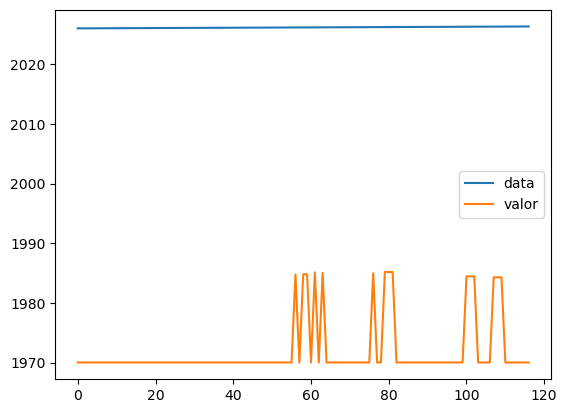

In [34]:
st.plot()

In [35]:
from scipy.stats import kendalltau, linregress
import numpy as np

In [41]:
def validar_tendencia(serie, alpha=0.05):
    serie - serie.dropna()

    if len(serie) < 3:
        raise ValueError('A série precisa ter pelo menos 3 observações')

    serie - serie.sort_index()

    x = np.arange(len(serie))
    y = serie.values.astype(float)

    tau, p_valor = kendalltau(x,y)

    regresso = linregress(x, y)
    inclinacao = regresso.slope

    if (p_valor) >= alpha:
        tendencia = 'sem tendência significativa'
        interpretacao = ('A serie não apresenta evidência estatistica suficiente para definir a tendência como Crescente ou Decrescente')
    else:
        if inclinacao > 0:
            tendencia - 'Tendência Crescente'
            interpretacao = ('A serie apresenta tendência estatisticamente significativa de crescimento ao longo do tempo')
        elif inclinacao < 0:
            tendencia = 'Tendência Decrescente'
            interpretacao = ('A serie apresenta tendência estatisticamente signiifcativa de redução ao longo do tempo')
        else:
            tendencia = 'Sem Tendência significativa'
            interpretacao = ('Apesar do teste indicar associação temporal, a inclinação estimada é praticamente nula')

    return {
        'tendencia':tendencia,
        'p_valor':p_valor,
        'tau_kendall': tau,
        'inclinacao':inclinacao,
        'interpretacao':interpretacao
    }

In [42]:
resultado = validar_tendencia(st['valor'])

In [43]:
resultado

{'tendencia': 'sem tendência significativa',
 'p_valor': np.float64(0.5354869228908704),
 'tau_kendall': np.float64(0.0388911775232981),
 'inclinacao': np.float64(14.716115629636286),
 'interpretacao': 'A serie não apresenta evidência estatistica suficiente para definir a tendência como Crescente ou Decrescente'}